In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [2]:
models = ['pcv1', 'pcv2-l24-d0768', 'pcv2-l48-d1024', 'pcv2-l48-d1536', 'evo2', 'gpn', 'pdllm']

In [3]:
tis_files = ['TIS_1', 'TIS_2', 'TIS_3']
data_types = ['conserved', 'neutral']

results = {}

for dtype in data_types:
    data_list = []
    
    for tis in tis_files:
        print(f"Processing {dtype} {tis}...")
        df = pd.read_csv(f'../../../results/Poaceae_CDS_PhyloP/8k/{dtype}_8k_{tis}.tsv', sep='\t')
        REF = df['Seq'].str[4095]
        
        for model in models:
            print(f"  Processing {model}...")
            if 'pcv2' not in model:
                logitPath = f'../../../results/Poaceae_CDS_PhyloP/8k/{dtype}_8k_{tis}_{model}.tsv'
            else:
                logitPath = f'../../../results/Poaceae_CDS_PhyloP/8k/{dtype}_8k_{tis}_{model}_logits.tsv'
            
            logits = pd.read_csv(logitPath, header=None, sep='\t')
            logits.columns = ['A', 'C', 'G', 'T']
            scores = df.apply(lambda row: logits.loc[row.name, REF.loc[row.name]], axis=1)
            df[model] = scores
        
        data_list.append(df)
    
    results[dtype] = pd.concat(data_list, ignore_index=True)

Processing conserved TIS_1...
  Processing pcv1...
  Processing pcv2-l24-d0768...
  Processing pcv2-l48-d1024...
  Processing pcv2-l48-d1536...
  Processing evo2...
  Processing gpn...
  Processing pdllm...
Processing conserved TIS_2...
  Processing pcv1...
  Processing pcv2-l24-d0768...
  Processing pcv2-l48-d1024...
  Processing pcv2-l48-d1536...
  Processing evo2...
  Processing gpn...
  Processing pdllm...
Processing conserved TIS_3...
  Processing pcv1...
  Processing pcv2-l24-d0768...
  Processing pcv2-l48-d1024...
  Processing pcv2-l48-d1536...
  Processing evo2...
  Processing gpn...
  Processing pdllm...
Processing neutral TIS_1...
  Processing pcv1...
  Processing pcv2-l24-d0768...
  Processing pcv2-l48-d1024...
  Processing pcv2-l48-d1536...
  Processing evo2...
  Processing gpn...
  Processing pdllm...
Processing neutral TIS_2...
  Processing pcv1...
  Processing pcv2-l24-d0768...
  Processing pcv2-l48-d1024...
  Processing pcv2-l48-d1536...
  Processing evo2...
  Processin

In [4]:
conserved = results['conserved']
neutral = results['neutral']

In [5]:
conserved['label'] = 1
neutral['label'] = 0

combined_df = pd.concat([conserved, neutral], ignore_index=True)
y_true = combined_df['label']

In [6]:
models = combined_df.columns[6:].tolist()[:-1]
models

['pcv1',
 'pcv2-l24-d0768',
 'pcv2-l48-d1024',
 'pcv2-l48-d1536',
 'evo2',
 'gpn',
 'pdllm']

In [7]:
results = []

for mdl in models:
    y_scores = combined_df[mdl]
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    results.append({'model': mdl, 'context': 8192, 'roc_auc': roc_auc})
results_df = pd.DataFrame(results)

In [8]:
results_df

,model,context,roc_auc
0,pcv1,8192,0.643732
1,pcv2-l24-d0768,8192,0.631885
2,pcv2-l48-d1024,8192,0.664748
3,pcv2-l48-d1536,8192,0.670275
4,evo2,8192,0.533502
5,gpn,8192,0.550973
6,pdllm,8192,0.493220


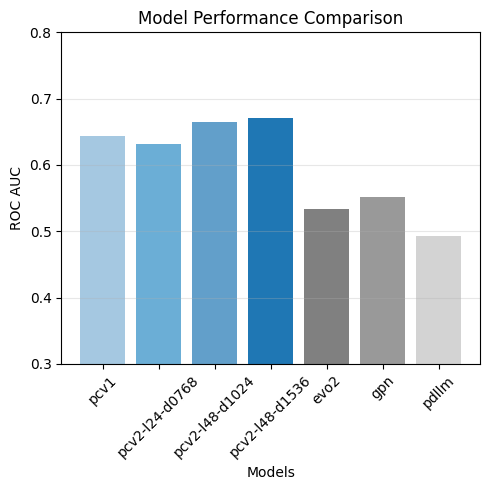

In [9]:
plt.figure(figsize=(5, 5))
colors = ['#1f77b466', '#6baed6', '#1f77b4b3', '#1f77b4ff', '#808080', '#999999', '#d3d3d3']

bars = plt.bar(results_df['model'], results_df['roc_auc'], color=colors)

plt.xlabel('Models')
plt.ylabel('ROC AUC')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.ylim(0.3, 0.8)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('performance_compairson_boundary.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()